# DNA Isolation and DNA Spectrophotometry

**Objective:** Calculate DNA concentration and purity ratios (A260/A280,
A260/A230) from raw spectrophotometer absorbance readings.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/spectrophotometer_readings.csv")
df

,sample_id,a230,a260,a280
0,Sample_1,6.753,14.52,7.934
1,Sample_2,6.329,8.86,5.829
2,Sample_3,10.263,21.04,9.786


## Calculate concentration and purity ratios

In [2]:
DSDNA_FACTOR = 50  # ug/mL per A260 unit

df["conc_ug_ml"] = (df.a260 * DSDNA_FACTOR).round(1)
df["ratio_260_280"] = (df.a260 / df.a280).round(2)
df["ratio_260_230"] = (df.a260 / df.a230).round(2)

def assess(row):
    protein_ok = 1.75 <= row.ratio_260_280 <= 1.90
    solvent_ok = 2.0 <= row.ratio_260_230 <= 2.2
    if protein_ok and solvent_ok:
        return "Pure"
    if not protein_ok and not solvent_ok:
        return "Protein & solvent contamination"
    if not protein_ok:
        return "Possible RNA contamination" if row.ratio_260_280 > 1.90 else "Protein contamination"
    return "Solvent/salt contamination"

df["status"] = df.apply(assess, axis=1)
df

,sample_id,a230,a260,a280,conc_ug_ml,ratio_260_280,ratio_260_230,status
0,Sample_1,6.753,14.52,7.934,726.0,1.83,2.15,Pure
1,Sample_2,6.329,8.86,5.829,443.0,1.52,1.40,Protein & solvent contamination
2,Sample_3,10.263,21.04,9.786,1052.0,2.15,2.05,Possible RNA contamination


## Visualise purity ratios

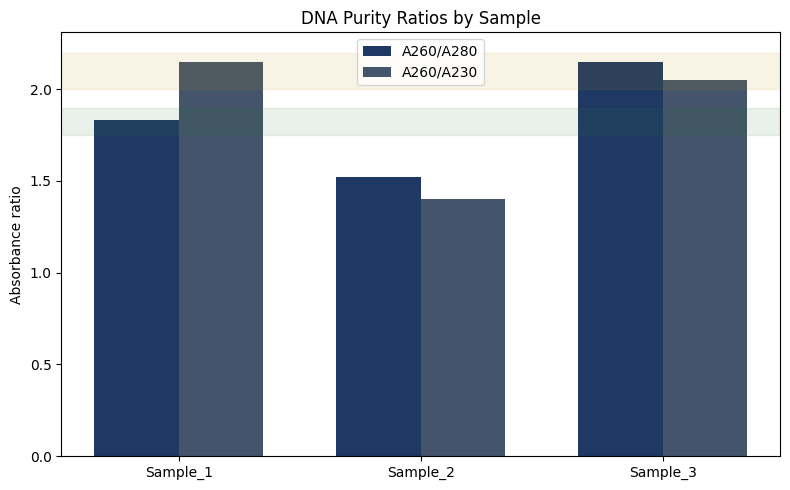

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df))
width = 0.35
ax.bar([i - width/2 for i in x], df.ratio_260_280, width, label="A260/A280", color="#1F3864")
ax.bar([i + width/2 for i in x], df.ratio_260_230, width, label="A260/A230", color="#44546A")
ax.axhspan(1.75, 1.90, color="#2E7D32", alpha=0.1)
ax.axhspan(2.0, 2.2, color="#B7950B", alpha=0.1)
ax.set_xticks(list(x))
ax.set_xticklabels(df.sample_id)
ax.set_ylabel("Absorbance ratio")
ax.set_title("DNA Purity Ratios by Sample")
ax.legend()
plt.tight_layout()
plt.savefig("dna_purity_ratios.png", dpi=150)
plt.show()

## Summary

Sample_1 fell within acceptable ranges for both purity ratios and is
classified as pure, high-quality DNA. Sample_2 showed low ratios on both
metrics, indicating combined protein and solvent/salt contamination.
Sample_3 showed an elevated A260/A280 ratio, suggesting possible RNA
co-purification despite an acceptable A260/A230 ratio.
